In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tqdm
import random
from collections import Counter, defaultdict
from scipy import integrate
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.cm as cm
import tqdm
import matplotlib.ticker as ticker
from sklearn.metrics import r2_score
import scipy
from sklearn.linear_model import LinearRegression
import time
import sys
import os

sys.path.append(os.path.dirname(os.getcwd())) # define path to the project for convenoent relative import

from simulation.SEIR_model import SEIRModel
from simulation.model_output import SEIRModelOutput
from simulation.error_model import NaiveErrorModel

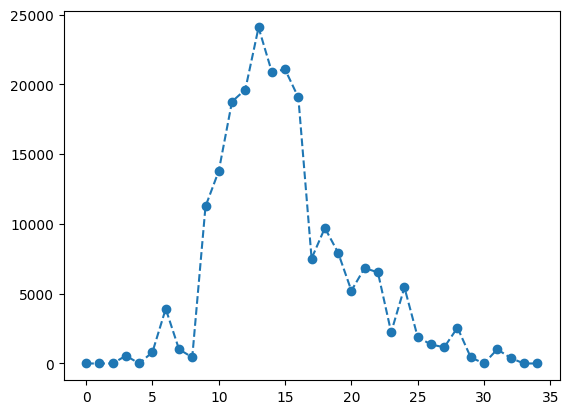

In [2]:
data = pd.read_csv('../data/wave_2014-2015_spb.csv', sep='\t', index_col=0)
weekly_incidence_data = data['total_cases'].to_numpy()[18:-6]
plt.plot(weekly_incidence_data, '--o')

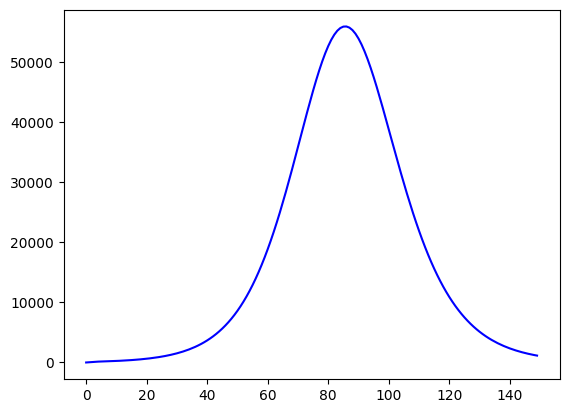

In [3]:
model = SEIRModel(population=5*1e6)
R_0 = 2

t_incubation = 2 # in days
t_infective = 4 # in days

gamma = 1/t_incubation
delta = 1/t_infective
beta = delta*R_0
init_inf_frac = 0.0001
init_rec_frac = 0.2
tmax = 150 # days

res = model.simulate( beta=beta, gamma=gamma, delta=delta, init_inf_frac=init_inf_frac, init_rec_frac=init_rec_frac)

plt.plot(res.daily_incidence, color='blue', alpha=1)

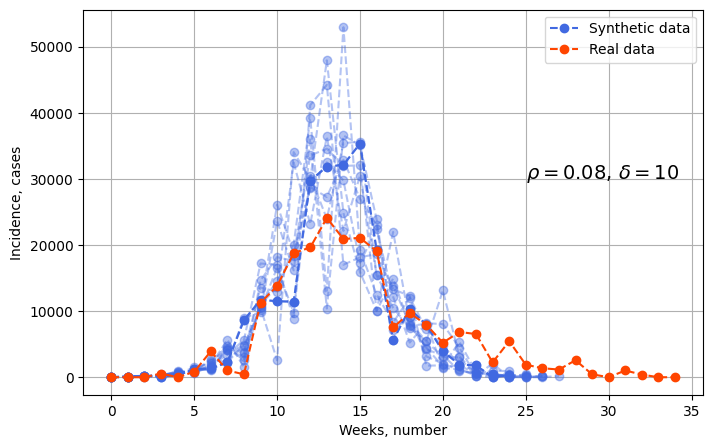

In [36]:
mean_delay = 10
mean_underreporting = 0.08

fig, ax = plt.subplots(figsize=(8, 5))
ax.text(25, 30000, r'$\rho = ${}, $\delta = ${}'.format(mean_underreporting, mean_delay), fontsize=14)
for _ in range(10):
    error_model = NaiveErrorModel(res.daily_incidence, 
                              mean_delay=mean_delay, 
                              mean_underreporting=mean_underreporting, 
                              error_mode='random')
    error_model.add_noise()
    ax.plot(error_model.weekly_incidence, '--o', color='RoyalBlue', alpha=0.4)

ax.plot(error_model.weekly_incidence, '--o', color='RoyalBlue', label='Synthetic data')
ax.plot(weekly_incidence_data, '--o', color='OrangeRed', label='Real data')
ax.set_xlabel('Weeks, number')
ax.set_ylabel('Incidence, cases')
ax.legend()
ax.grid()
fig.savefig('../figures/weekly_noised_data.pdf', bbox_inches='tight')
fig.savefig('../figures/weekly_noised_data.png', bbox_inches='tight', dpi=600)